Rewriting and consolidating the looped data runs and plotting functions. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import pandas as pd
import seaborn as sns


In [18]:
#Set up the path for the FEAST output from the loops: 
path_to_loop_results  = 'run_results_loop_test/'
subfolders = [subfold for subfold in os.listdir(path_to_loop_results)]

#Then create the dataframe to catch the output summary data from the runs: 
looped_results = pd.DataFrame(columns = ['program', 'val_avg', 'val_var', 'threshold', 'cadence', 'cadence_days'])
counter = -1

for indx in range(len(subfolders)):

    #split out the info we need from the folder names: 
    split_folder_name = subfolders[indx].split('_')
    threshold = int(split_folder_name[1])
    cadence = split_folder_name[3]
    cadence_days = int(split_folder_name[4])

    #Once you have that subfolder info, pull out the json files within that subfolder: 
    path_to_json = path_to_loop_results + subfolders[indx] + '/'
    json_files = [pos_json for pos_json in os.listdir(path_to_json) if pos_json.endswith('.json')]

    for i in range(len(json_files)):
        read_file = path_to_json + str(json_files[i])
        df = json.load(open(read_file))

        #okay - individual file loaded; lets loop through each file and grab the average emissions for each LDAR program. 
        for j in df.keys():
            if j.lower() == "time": #skip the time object
                break
            #Calculate the average emissions value and varainace for the full time series for each LDAR Program: 
            avg_em = np.mean(np.array(df[j]['emission timeseries']))
            var_em = np.var(np.array(df[j]['emission timeseries']))

            #Step up the counter: 
            counter += 1 

            #write to location: Not elegent, but I was frustrated with the more sophisticated solutions, 
            # a better python-ish can fix this :) 
            looped_results.at[counter, 'program'] = j
            looped_results.at[counter, 'val_avg'] = avg_em
            looped_results.at[counter, 'val_var'] = var_em
            looped_results.at[counter, 'threshold'] = threshold
            looped_results.at[counter, 'cadence'] = cadence
            looped_results.at[counter, 'cadence_days'] = cadence_days


# Change the catagorical columns to catagory and re-order: 

looped_results['program'] = looped_results['program'].astype('category')
looped_results['cadence'] = looped_results['cadence'].astype('category')       

reordered = ['monthly', 'bimonthly', 'quarterly', 'semiannual', 'annual']
looped_results['cadence'] = looped_results['cadence'].cat.reorder_categories(reordered, ordered = True)

reordered_programs = ['quarterly_ogi', 'periodic', 'periodic_annual', 'satellite', 'satellite_annual', 'Null']
looped_results['program'] = looped_results['program'].cat.reorder_categories(reordered_programs, ordered = True)

Plot plot plot plot plot plot plot plot. Seaborn plots are MUCH EASIER and look nicer that the matplotlib, so that's what I'm building in here. The plots captured here are from a looped run that was only 2kg-hr, which I overwrote with the additional cadences run. 

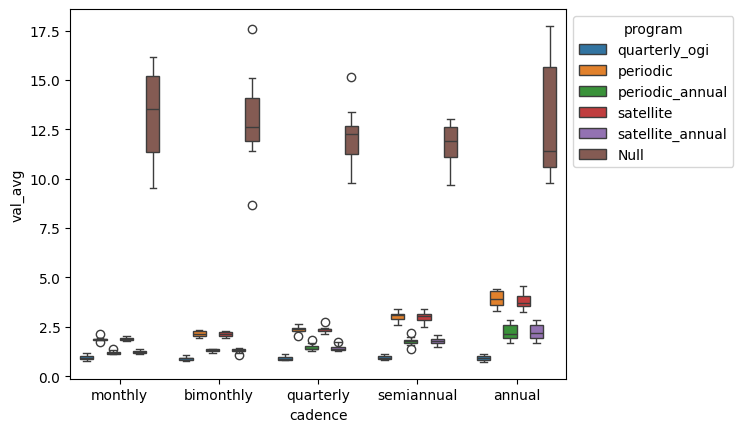

In [19]:
ax = sns.boxplot(data = looped_results, x = 'cadence', y = 'val_avg', hue = 'program')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))

Lets do that plot removing the Null case 

In [16]:
looped_results_ldar = looped_results[looped_results['program'] != 'Null']

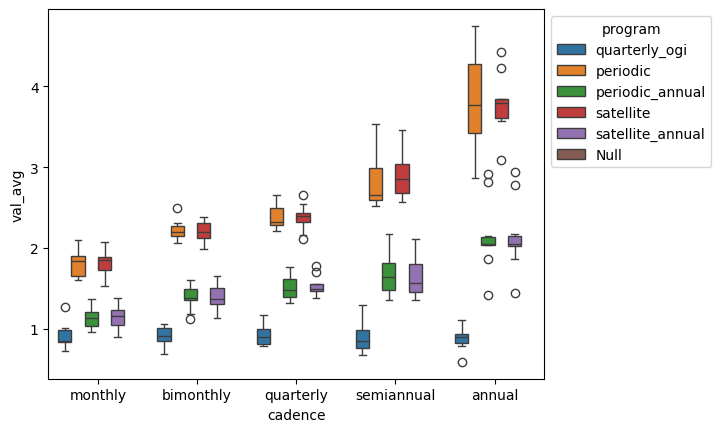

In [20]:
ax = sns.boxplot(data = looped_results_ldar, x = 'cadence', y = 'val_avg', hue = 'program')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))

Okay, cool - that looks marv. Going to do something else now, which is adjusting the run results slightly and then running three thresholds - 1, 2, and 5 kg/hr; 10 iterations each. 

In [116]:
#Set up the path for the FEAST output from the loops: 
path_to_loop_results  = 'run_results_loop_test/'
subfolders = [subfold for subfold in os.listdir(path_to_loop_results)]

#Then create the dataframe to catch the output summary data from the runs: 
looped_results = pd.DataFrame(columns = ['program', 'val_avg', 'val_var', 'threshold', 'cadence', 'cadence_days'])
counter = -1

#pull the indexs for the last year of data: 
indx_high = 5*365
indx_low = (5*365) - 364


for indx in range(len(subfolders)):

    #split out the info we need from the folder names: 
    split_folder_name = subfolders[indx].split('_')
    threshold = int(split_folder_name[1])
    cadence = split_folder_name[3]
    cadence_days = int(split_folder_name[4])

    #Once you have that subfolder info, pull out the json files within that subfolder: 
    path_to_json = path_to_loop_results + subfolders[indx] + '/'
    json_files = [pos_json for pos_json in os.listdir(path_to_json) if pos_json.endswith('.json')]

    for i in range(len(json_files)):
        read_file = path_to_json + str(json_files[i])
        df = json.load(open(read_file))

        
        #okay - individual file loaded; lets loop through each file and grab the average emissions for each LDAR program. 
        for j in df.keys():
            if j.lower() == "time": #skip the time object
                break
            
            #Calculate the average emissions value and varainace for the full time series for each LDAR Program: 
            avg_em = np.mean(np.array(df[j]['emission timeseries'][indx_low:indx_high]))
            var_em = np.var(np.array(df[j]['emission timeseries'][indx_low:indx_high]))

            #Step up the counter: 
            counter += 1 

            #write to location: Not elegent, but I was frustrated with the more sophisticated solutions, 
            # a better python-ish can fix this :) 
            looped_results.at[counter, 'program'] = j
            looped_results.at[counter, 'val_avg'] = avg_em
            looped_results.at[counter, 'val_var'] = var_em
            looped_results.at[counter, 'threshold'] = threshold
            looped_results.at[counter, 'cadence'] = cadence
            looped_results.at[counter, 'cadence_days'] = cadence_days


# Change the catagorical columns to catagory and re-order: 

looped_results['program'] = looped_results['program'].astype('category')
looped_results['cadence'] = looped_results['cadence'].astype('category')       

reordered = ['monthly', 'bimonthly', 'quarterly', 'semiannual', 'annual']
looped_results['cadence'] = looped_results['cadence'].cat.reorder_categories(reordered, ordered = True)

reordered_programs = ['quarterly_ogi', 'periodic', 'periodic_annual', 'satellite', 'satellite_annual', 'Null']
looped_results['program'] = looped_results['program'].cat.reorder_categories(reordered_programs, ordered = True)

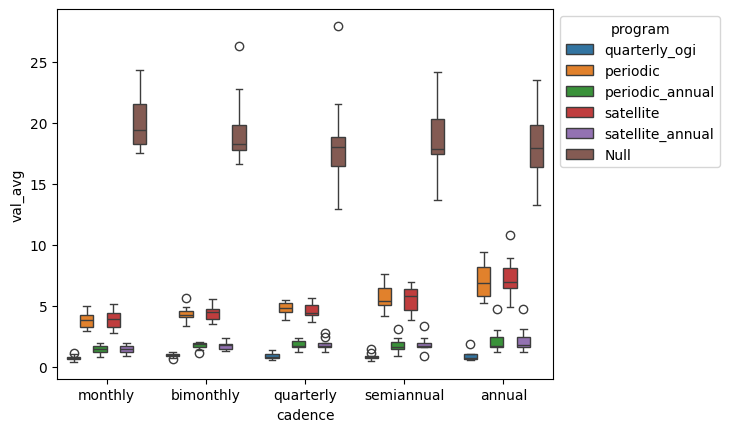

In [117]:
ax = sns.boxplot(data = looped_results[looped_results['threshold'] == 5], x = 'cadence', y = 'val_avg', hue = 'program')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))

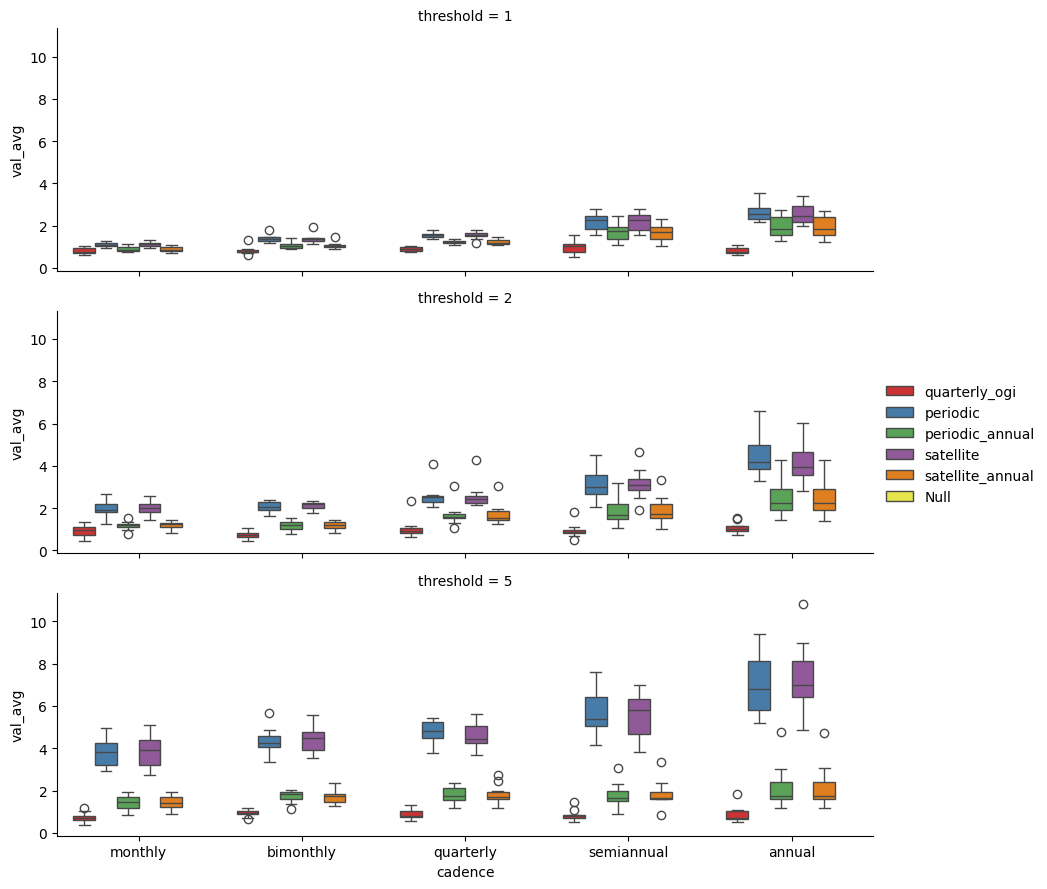

In [118]:
g = sns.FacetGrid(looped_results[looped_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3)
g.map_dataframe(sns.boxplot,  x = 'cadence', y = 'val_avg',  hue = 'program',palette='Set1' ).add_legend()


Cool, alright. Lets try something else here...lets look at differences from  quarterly OGI. We need to start this with a summary function to get averages of the programs...lets try with groupby http://stackoverflow.com/questions/29314424/pandas-using-groupby-to-get-mean-for-each-data-category. Ah, we needed reset_index! https://stackoverflow.com/questions/31569549/how-to-groupby-a-dataframe-in-pandas-and-keep-columns

In [122]:
check = looped_results.groupby(['program','cadence', 'threshold'])['val_avg'].mean().reset_index()
# print(check)

C:\Users\hhallida\AppData\Local\Temp\ipykernel_66964\2445547731.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  check = looped_results.groupby(['program','cadence', 'threshold'])['val_avg'].mean().reset_index()


https://stackoverflow.com/questions/22591174/pandas-multiple-conditions-while-indexing-data-frame-unexpected-behavior\

In [173]:
#hmhmhmhmhmh....okay lets see here, how do we want to do this...
quartogi = check[check['program'] == "quarterly_ogi"]
programs = check[check['program'] != "quarterly_ogi"]

ratioed_results = pd.DataFrame(columns = ['program', 'val', 'threshold', 'cadence'])
counter = -1

for i in range(len(programs)):

    #for each index pull the cadence and threshold: 
    cad = programs.iloc[i, programs.columns.get_loc('cadence')]
    thrs = programs.iloc[i, programs.columns.get_loc('threshold')]
    #Then use those to pull the quarterly OGI row: 
    grab = quartogi[(quartogi['cadence'] == cad) & (quartogi['threshold'] == thrs)]
    #once you have that, calculate the difference (or ratio?): 
    val = pd.to_numeric(programs.iloc[i, programs.columns.get_loc('val_avg')]) - pd.to_numeric(grab['val_avg'].values[0])

    #writeout: 
    counter += 1
    ratioed_results.at[counter, 'program'] = programs.iloc[i, programs.columns.get_loc('program')]
    ratioed_results.at[counter, 'threshold'] = thrs
    ratioed_results.at[counter, 'cadence'] = cad
    ratioed_results.at[counter, 'val'] = val
    #
    

In [168]:
grab = quartogi[(quartogi['cadence'] == 'monthly') & (quartogi['threshold'] == 2)]
print(pd.to_numeric(grab['val_avg'].values[0]))


0.9010498563475171


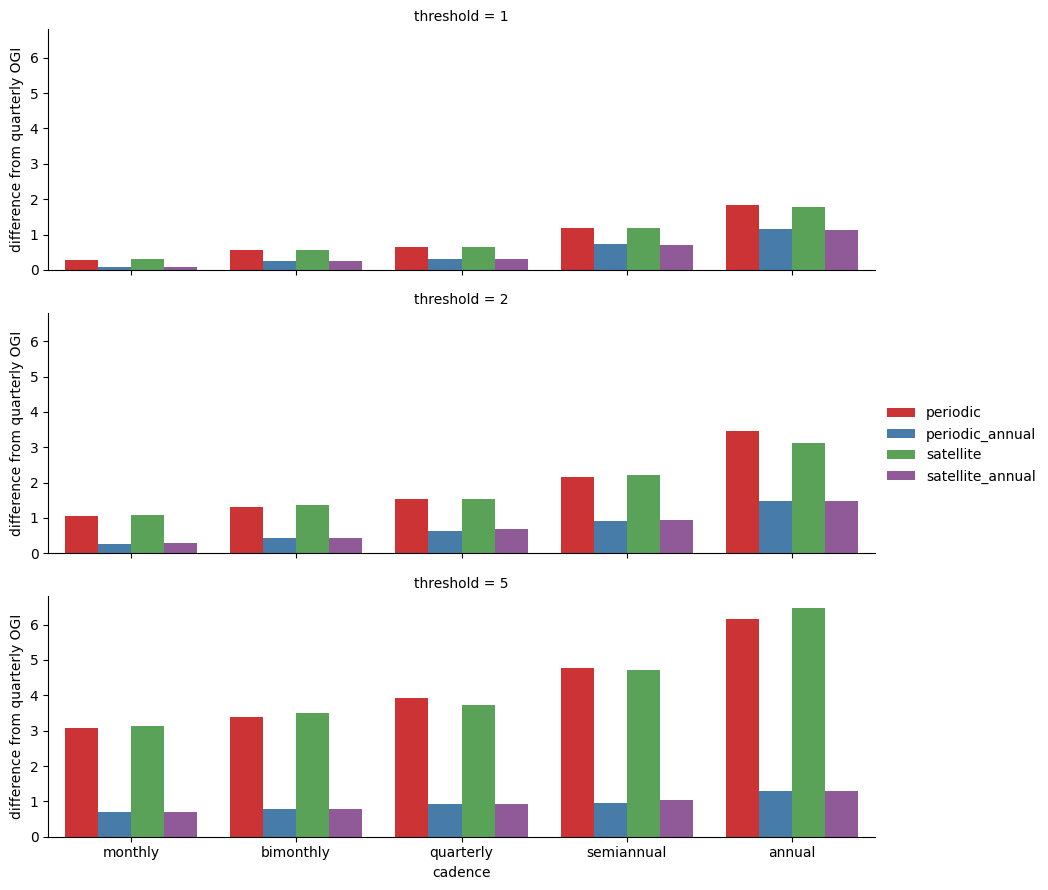

In [ ]:
g = sns.FacetGrid(ratioed_results[ratioed_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3, )
g.map_dataframe(sns.barplot,  x = 'cadence', y = 'val',  hue = 'program',palette='Set1' ).add_legend().set(ylabel='Difference from quarterly OGI')


# ax = sns.barplot(data = ratioed_results[ratioed_results['threshold'] == 5], x = 'cadence', y = 'val', hue = 'program')


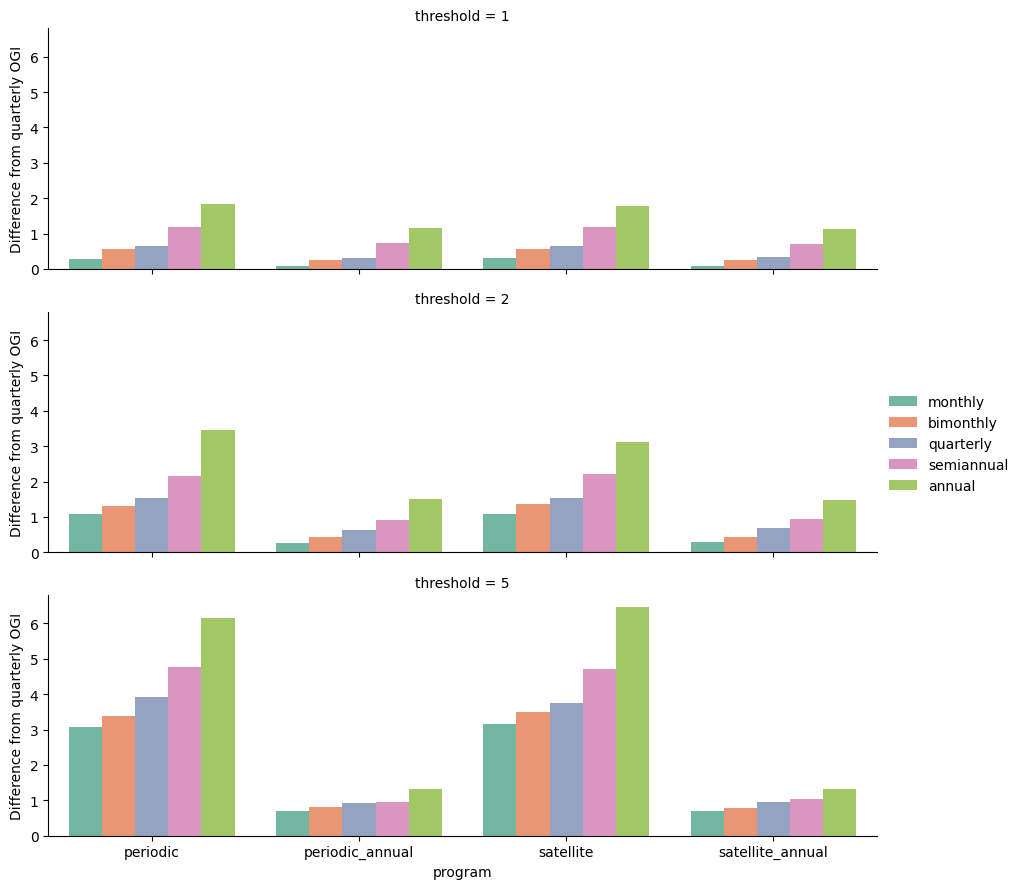

In [182]:
g = sns.FacetGrid(ratioed_results[ratioed_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3, )
g.map_dataframe(sns.barplot,  x = 'program', y = 'val',  hue = 'cadence',palette='Set2' ).add_legend().set(ylabel='Difference from quarterly OGI')
